In [ ]:
!pip install kagglehub -q

import kagglehub
import os
import pandas as pd

path = kagglehub.dataset_download("taruntiwarihp/elon-musk-tweets")
print("Dataset path:", path)
print("Files:", os.listdir(path))

100%|██████████| 1.07M/1.07M [00:00<00:00, 104MB/s]

Extracting files...
Dataset path: /root/.cache/kagglehub/datasets/taruntiwarihp/elon-musk-tweets/versions/1
Files: ['Elon Musk.csv']


In [ ]:
csv_path = os.path.join(path, "Elon Musk.csv")   # adjust if needed
df = pd.read_csv(csv_path)

print(df.shape)
print(df.columns)
df.head()

(25757, 3)
Index(['Unnamed: 0', 'tweets', 'sentiment'], dtype='object')


,Unnamed: 0,tweets,sentiment
0,0,@elonmusk @realfuckingnews @business Ancient c...,pos
1,1,"@elonmusk @rockstardenied @SpaceX Very kind, a...",pos
2,2,@elonmusk What will happen to Dodge?,pos
3,3,RT @_0121Dan: Day 8 of tweeting @elonmusk and ...,neg
4,4,@rockstardenied @elonmusk @SpaceX Download the...,pos


In [ ]:
df = df[["tweets", "sentiment"]].copy()
df = df.dropna(subset=["tweets", "sentiment"])

df["tweets"] = df["tweets"].astype(str)
df["sentiment"] = df["sentiment"].astype(str).str.lower().str.strip()

# keep only valid labels
df = df[df["sentiment"].isin(["pos", "neg"])].reset_index(drop=True)

print(df["sentiment"].value_counts())
df.head()

sentiment
pos    22725
neg     3032
Name: count, dtype: int64


,tweets,sentiment
0,@elonmusk @realfuckingnews @business Ancient c...,pos
1,"@elonmusk @rockstardenied @SpaceX Very kind, a...",pos
2,@elonmusk What will happen to Dodge?,pos
3,RT @_0121Dan: Day 8 of tweeting @elonmusk and ...,neg
4,@rockstardenied @elonmusk @SpaceX Download the...,pos


In [ ]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"rt\s+", "", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["tweets"].apply(clean_text)
df[["tweets", "clean_text", "sentiment"]].head()

,tweets,clean_text,sentiment
0,@elonmusk @realfuckingnews @business Ancient c...,ancient crypto that s math when i first learne...,pos
1,"@elonmusk @rockstardenied @SpaceX Very kind, a...",very kind appreciate you much more,pos
2,@elonmusk What will happen to Dodge?,what will happen to dodge,pos
3,RT @_0121Dan: Day 8 of tweeting @elonmusk and ...,day 8 of tweeting and asking him to buy birmin...,neg
4,@rockstardenied @elonmusk @SpaceX Download the...,download the app pi available on app store and...,pos


Encode labels:

In [ ]:
label_map = {"neg": 0, "pos": 1}
df["label"] = df["sentiment"].map(label_map)

print(df["label"].value_counts())

label
1    22725
0     3032
Name: count, dtype: int64


Split data:

In [ ]:
from sklearn.model_selection import train_test_split

X_text = df["clean_text"].values
y = df["label"].values

X_train_text, X_temp_text, y_train, y_temp = train_test_split(
    X_text, y, test_size=0.30, random_state=42, stratify=y
)

X_val_text, X_test_text, y_val, y_test = train_test_split(
    X_temp_text, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Train:", len(X_train_text))
print("Validation:", len(X_val_text))
print("Test:", len(X_test_text))

Train: 18029
Validation: 3864
Test: 3864


tokenize and pad

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer, tokenizer_from_json
from tensorflow.keras.preprocessing.sequence import pad_sequences

vocab_size = 10000
max_len = 40
oov_token = "<OOV>"

tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_token)
tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_val_seq = tokenizer.texts_to_sequences(X_val_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

X_train = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
X_val = pad_sequences(X_val_seq, maxlen=max_len, padding="post", truncating="post")
X_test = pad_sequences(X_test_seq, maxlen=max_len, padding="post", truncating="post")

print(X_train.shape, X_val.shape, X_test.shape)

(18029, 40) (3864, 40) (3864, 40)


Part 2: Downloading a Sample Model

In [ ]:
tokenizer_json = tokenizer.to_json()

with open("tokenizer.json", "w") as f:
    f.write(tokenizer_json)

with open("tokenizer.json", "r") as f:
    loaded_tokenizer = tokenizer_from_json(f.read())

print("Tokenizer loaded successfully.")

Tokenizer loaded successfully.


In [ ]:
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

reference_lstm_model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=64,
        input_length=max_len,
        mask_zero=False   # <<< CHANGE THIS TO FALSE
    ),
    LSTM(64),             # keep defaults so it can use cuDNN
    Dense(1, activation="sigmoid")
])
reference_lstm_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Part 3: Model Building

Model A — RNN + LSTM

In [ ]:
from tensorflow.keras.layers import LSTM, SimpleRNN, Dropout, Dense, Embedding
from tensorflow.keras import Sequential

def build_rnn_lstm_model(vocab_size, max_len):
    model = Sequential([
        Embedding(
            input_dim=vocab_size,
            output_dim=64,
            input_length=max_len,
            mask_zero=False   # no masking at all
        ),
        SimpleRNN(32, return_sequences=True),
        LSTM(64),           # remove all custom args, let TF pick cuDNN
        Dropout(0.3),
        Dense(32, activation="relu"),
        Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

Model B — RNN + GRU

In [ ]:
from tensorflow.keras.layers import GRU

def build_rnn_gru_model(vocab_size, max_len):
    model = Sequential([
        Embedding(
            input_dim=vocab_size,
            output_dim=64,
            input_length=max_len,
            mask_zero=False   # same setting
        ),
        SimpleRNN(32, return_sequences=True),
        GRU(64),            # default cuDNN-capable GRU
        Dropout(0.3),
        Dense(32, activation="relu"),
        Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [ ]:
rnn_lstm_model = build_rnn_lstm_model(vocab_size, max_len)
rnn_gru_model  = build_rnn_gru_model(vocab_size, max_len)

train both models

In [ ]:
import time

epochs = 10
batch_size = 32

start_time = time.time()
history_lstm = rnn_lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)
lstm_train_time = time.time() - start_time

start_time = time.time()
history_gru = rnn_gru_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)
gru_train_time = time.time() - start_time

Epoch 1/10
564/564 ━━━━━━━━━━━━━━━━━━━━ 37s 59ms/step - accuracy: 0.8820 - loss: 0.3585 - val_accuracy: 0.8822 - val_loss: 0.3527
Epoch 2/10
564/564 ━━━━━━━━━━━━━━━━━━━━ 32s 57ms/step - accuracy: 0.8821 - loss: 0.3493 - val_accuracy: 0.8822 - val_loss: 0.3559
Epoch 3/10
564/564 ━━━━━━━━━━━━━━━━━━━━ 34s 59ms/step - accuracy: 0.8824 - loss: 0.3508 - val_accuracy: 0.8856 - val_loss: 0.3506
Epoch 4/10
564/564 ━━━━━━━━━━━━━━━━━━━━ 33s 58ms/step - accuracy: 0.8852 - loss: 0.3475 - val_accuracy: 0.8864 - val_loss: 0.3477
Epoch 5/10
564/564 ━━━━━━━━━━━━━━━━━━━━ 31s 56ms/step - accuracy: 0.8766 - loss: 0.3590 - val_accuracy: 0.8822 - val_loss: 0.3437
Epoch 6/10
564/564 ━━━━━━━━━━━━━━━━━━━━ 33s 58ms/step - accuracy: 0.8823 - loss: 0.3198 - val_accuracy: 0.8822 - val_loss: 0.3201
Epoch 7/10
564/564 ━━━━━━━━━━━━━━━━━━━━ 33s 58ms/step - accuracy: 0.9000 - loss: 0.2702 - val_accuracy: 0.8693 - val_loss: 0.3335
Epoch 8/10
564/564 ━━━━━━━━━━━━━━━━━━━━ 31s 56ms/step - accuracy: 0.9225 - loss: 0.2279 - 

Part 4: Evaluation and Comparison

121/121 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step
121/121 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step
RNN + LSTM Accuracy: 0.8747
RNN + GRU Accuracy: 0.9247

=== Classification Report: RNN + LSTM ===
              precision    recall  f1-score   support

         neg       0.46      0.35      0.40       455
         pos       0.92      0.94      0.93      3409

    accuracy                           0.87      3864
   macro avg       0.69      0.65      0.66      3864
weighted avg       0.86      0.87      0.87      3864


=== Classification Report: RNN + GRU ===
              precision    recall  f1-score   support

         neg       0.75      0.53      0.63       455
         pos       0.94      0.98      0.96      3409

    accuracy                           0.92      3864
   macro avg       0.85      0.76      0.79      3864
weighted avg       0.92      0.92      0.92      3864


Confusion Matrix - RNN + LSTM
[[ 159  296]
 [ 188 3221]]

Confusion Matrix - RNN + GRU
[[ 243  212]
 [  79 3330]]


,Model,Accuracy,Training Time (sec)
0,RNN + LSTM,0.874741,328.035469
1,RNN + GRU,0.924689,362.764631


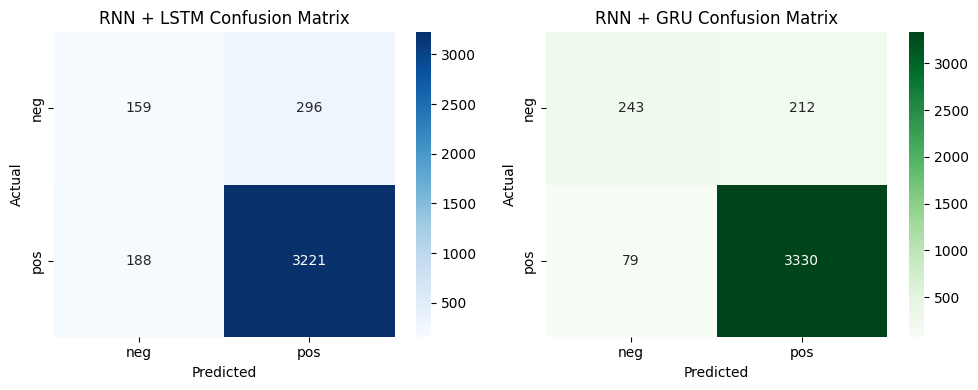

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Predict probabilities
y_prob_lstm = rnn_lstm_model.predict(X_test)
y_prob_gru = rnn_gru_model.predict(X_test)

# Convert probabilities to binary class labels
y_pred_lstm = (y_prob_lstm > 0.5).astype(int).flatten()
y_pred_gru = (y_prob_gru > 0.5).astype(int).flatten()

# Accuracy
acc_lstm = accuracy_score(y_test, y_pred_lstm)
acc_gru = accuracy_score(y_test, y_pred_gru)

print("RNN + LSTM Accuracy:", round(acc_lstm, 4))
print("RNN + GRU Accuracy:", round(acc_gru, 4))

# Classification reports
print("\n=== Classification Report: RNN + LSTM ===")
print(classification_report(y_test, y_pred_lstm, target_names=["neg", "pos"]))

print("\n=== Classification Report: RNN + GRU ===")
print(classification_report(y_test, y_pred_gru, target_names=["neg", "pos"]))

# Confusion matrices
cm_lstm = confusion_matrix(y_test, y_pred_lstm)
cm_gru = confusion_matrix(y_test, y_pred_gru)

print("\nConfusion Matrix - RNN + LSTM")
print(cm_lstm)

print("\nConfusion Matrix - RNN + GRU")
print(cm_gru)

# Summary table
results_df = pd.DataFrame({
    "Model": ["RNN + LSTM", "RNN + GRU"],
    "Accuracy": [acc_lstm, acc_gru],
    "Training Time (sec)": [lstm_train_time, gru_train_time]
})

display(results_df)

# Plot confusion matrices
labels = ["neg", "pos"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.heatmap(cm_lstm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title("RNN + LSTM Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_gru, annot=True, fmt="d", cmap="Greens",
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title("RNN + GRU Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

plot training curves

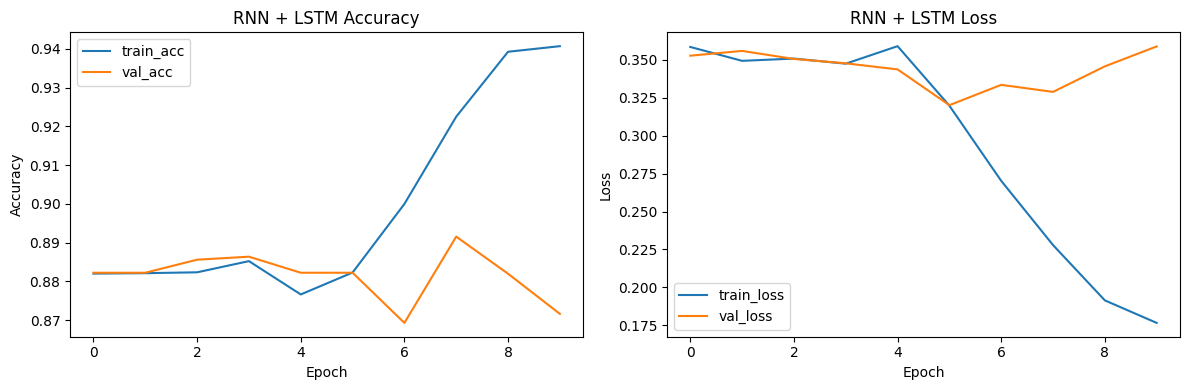

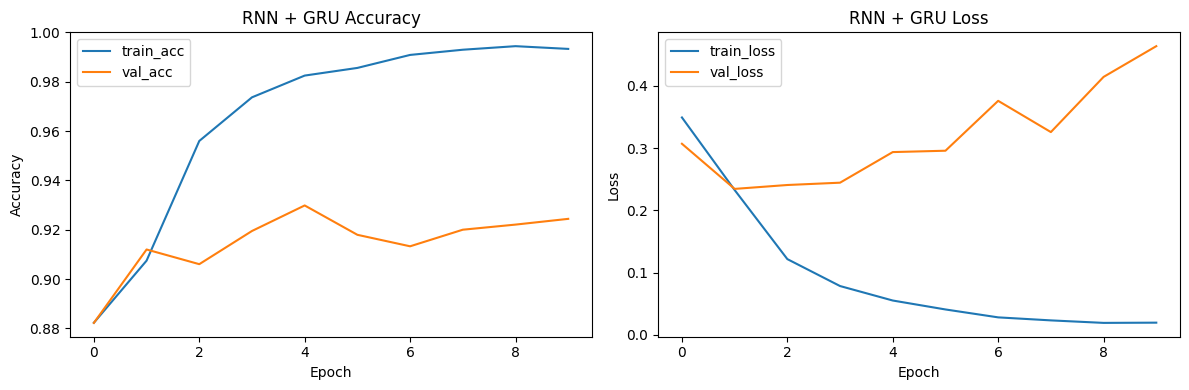

In [ ]:
def plot_history(history, title):
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(history.history["accuracy"], label="train_acc")
    plt.plot(history.history["val_accuracy"], label="val_acc")
    plt.title(f"{title} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history["loss"], label="train_loss")
    plt.plot(history.history["val_loss"], label="val_loss")
    plt.title(f"{title} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history_lstm, "RNN + LSTM")
plot_history(history_gru, "RNN + GRU")